# Point-E Baseline Inference & Visual Debugging

This notebook provides an isolated, visual environment to run the Point-E baseline model on a single pothole image. It demonstrates our modular architecture by utilizing the OOP engine to run inference, evaluating the 3D anomaly depth metric (P05), and generating an interactive 3D plot.

In [1]:
# Ensure project root is in path and set as Current Working Directory
import sys
import os
from pathlib import Path

# Idempotent way to find the project root
current_path = Path(os.getcwd())
if current_path.name == 'notebooks':
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path

# Change working directory so Point-E saves/loads the cache at the project root
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import json
import numpy as np
import plotly.graph_objects as go
from PIL import Image
import torch

# Import our Modular Architecture functions
from src.models.point_e_model import PotholePointE
from src.evaluation.evaluate_3d import calculate_p05_depth, classify_severity

## 1. Global Configurations
Define metadata and dataset directory targets. We establish `SAMPLE_INDEX` to allow us to easily switch which image we are visualizing.

In [2]:
IMAGES_DIR = PROJECT_ROOT / "data" / "processed" / "point_e_ready" / "images"
HEATMAPS_DIR = PROJECT_ROOT / "data" / "processed" / "point_e_ready" / "heatmaps"
METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "point_e_ready" / "metadata.json"

SAMPLE_INDEX = 100  # Change this index to inspect different images

## 2. Load Sample Image and Metadata

Loaded Image: 20250227_173306.png
Real-World Mapping Scale: 583.2290123980978 meters

--- Original RGB Image ---


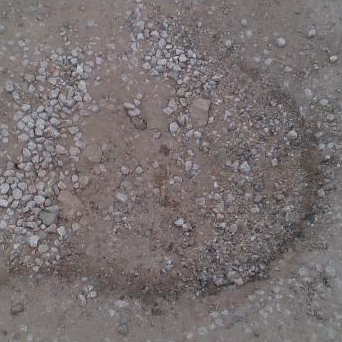


--- Associated 2D Heatmap ---


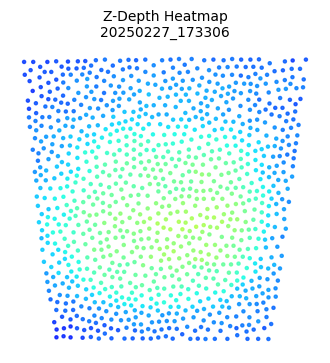

In [3]:
# Ensure data paths exist
assert IMAGES_DIR.exists(), "Images directory not found."
assert METADATA_PATH.exists(), "Metadata file not found."

# Load scale mapping dictionary
with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)
scales_dict = metadata.get("scales", {})

# Fetch desired image dynamically based on valid extensions
image_paths = [p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in {'.jpg', '.png', '.jpeg'}]
sample_path = image_paths[SAMPLE_INDEX]
stem = sample_path.stem
scale = scales_dict.get(stem, 1.0)

print(f"Loaded Image: {sample_path.name}")
print(f"Real-World Mapping Scale: {scale} meters")

# Render 2D Image Preview inside the Notebook
img = Image.open(sample_path)
img.thumbnail((400, 400))
print("\n--- Original RGB Image ---")
display(img)

# Try fetching and rendering the associated Heatmap if it exists
heatmap_path = HEATMAPS_DIR / f"{sample_path.stem}_heatmap.png"
if heatmap_path.exists():
    print("\n--- Associated 2D Heatmap ---")
    hm_img = Image.open(heatmap_path)
    hm_img.thumbnail((400, 400))
    display(hm_img)
else:
    print(f"\nNo associated heatmap found in {HEATMAPS_DIR.name}.")

## 3. Initialize Point-E Engine
Here we instantiate the pure object-oriented engine. This operation automatically allocates the Point-E parameters into GPU VRAM (if available CUDA is detected).

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Allocating models to: {device}")

model = PotholePointE(device=device)

Allocating models to: cuda
Creating base model (base40M)...
Creating upsample model (upsample)...
Downloading/Loading baseline checkpoint from custom cache: C:\Users\AdriBom\Documents\Repos\dgm-2026.1\projects\multimodal-pothole-detection\point_e_model_cache
Downloading/Loading upsampler checkpoint from custom cache...


## 4. Run Baseline Inference
We safely pass the loaded Pillow `Image` directly to the `model.predict()` method. The model generates the local 3D points, and applies the `scale` factor mapped from our JSON to intrinsically de-normalize the depths.

In [5]:
coords = model.predict(img, scale)
print(f"Generated Point Cloud Output Array Shape: {coords.shape}")

Generated Point Cloud Output Array Shape: (4096, 3)


## 5. Metric Evaluation
Extract the 5th percentile severity limit (P05) focusing strictly on the negative Z-axis subspace. This actively filters deep artificial anomalies produced by the model's diffusion variance.

In [6]:
p05_depth = calculate_p05_depth(coords)
severity_class = classify_severity(p05_depth)

print("------- EVALUATION COMPUTED ------- ")
print(f"Estimated P05 Depth: {p05_depth:.4f} meters")
print(f"Engineering Classification: {severity_class}")

------- EVALUATION COMPUTED ------- 
Estimated P05 Depth: 0.2916 meters
Engineering Classification: Deep Base Failure


## 6. Interactive 3D Plot Visualizer
Deploying an interactive 3D spatial plot via `plotly` to zoom and rotate over the pothole structure.

In [7]:
x = coords[:, 0]
y = coords[:, 1]
z = coords[:, 2]

# Create an interactive 3D Scatter plot
fig = go.Figure(
    data=[go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=2,
            color=z, # Create depth heatmap via the Z axis
            colorscale='Jet',
            opacity=0.8
        )
    )]
)

# Standardize the aspect ratio to maintain geometric reality
fig.update_layout(
    title=f"Pothole 3D Reconstruction: {stem} | {severity_class}",
    scene=dict(
        aspectmode='data',
        xaxis_title='X (meters)',
        yaxis_title='Y (meters)',
        zaxis_title='Z Depth (meters)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

## 7. Open3D Native Visualization
For deeper geometric verification, we also render the output using `open3d`, which spawns a CAD-like external viewer. This provides continuity with our preprocessing visualization pipelines.

In [8]:
import open3d as o3d
import matplotlib.pyplot as plt

# Initialize Open3D PointCloud object
pcd_point_e = o3d.geometry.PointCloud()
pcd_point_e.points = o3d.utility.Vector3dVector(coords)

# Since our model engine strictly outputs XYZ coordinates, 
# we can map the Z-axis (Depth) into an RGB colormap for Open3D.
z_vals = coords[:, 2]
z_norm = (z_vals - z_vals.min()) / (z_vals.max() - z_vals.min() + 1e-8)

cmap = plt.get_cmap("jet")
colors_mapped = cmap(z_norm)[:, :3]  # Extract RGB, ignore Alpha

pcd_point_e.colors = o3d.utility.Vector3dVector(colors_mapped)

print("Opening external Open3D Viewer...")
# The view should pop up in a hardware-accelerated external window.
o3d.visualization.draw_geometries(
    [pcd_point_e], 
    window_name=f"Point-E Prediction: {stem} | {severity_class}",
    width=1024, 
    height=768
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Opening external Open3D Viewer...
